<a href="https://colab.research.google.com/github/zsevall/DSAI510/blob/main/DSAI541_Assignment_01_Zeynep_SEVAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 1 - Deadline: April 14, 2025, Monday 11pm

#### DSAI 541 Spring 2025

Complete the assignment below and upload <span style="color:red">both the .ipynb file and its pdf</span> to https://moodle.bogazici.edu.tr by the deadline given above. The submission page on Moodle will close automatically after this date and time and no late homeworks will be accepted.


To make a pdf, this may work if you're using Jupyter notebook on browser: Hit CMD+P or CTRL+P, and save it as PDF. You may also use other options from the File menu. (You can use Google Colab, but at the end you should download the ipynb notebook to submit it on Moodle.)

In [ ]:
# Run this cell first

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import HTML

# Set the display option to show all rows scrolling with a slider
pd.set_option('display.max_rows', None)
# To disable this, run the line below:
# pd.reset_option('display.max_rows')

# Problem 1: Breast Cancer Classification via ANN in PyTorch (70 pts)
(You have to use PyTorch in this problem, Tensorflow will not be accepted as answer.)

a) Load the data in `Breast_Cancer_Wisconsin.csv` to a dataframe.

b) Check the data if there is any missing/NA/None values. If there is, fill them will mean, median or your choice of imputation.

c) Shuffle the dataframe first. Then, standardize the data and split the data as train, validation and test sets. (Do you standardize or split first to avoid data leakage?)

d) Train artificial neural network to predict if the cancer is benign or malignant. Utilize (automatic) early stopping not to overtrain the neurons. Use your choice of optimizer and hyperparameters (learning rate, number of neurons and layers etc) so that you get sensible training and validation curves (don't do hyperparameter tuning here, it'll come in the next problem). Make these plots side by side (see Lecture_7.ipynb):
Plot 1: Training and Validation Loss
Plot 2: Training and Validation Accuracy

e) Calculate accuracy, recall, precision and f1 scores on the test set and print them.

f) Generate confusion matrix and interpret the numbers. Calculate accuracy manually (show your algebra). Does it match the accuracy you calculated with code in the previous step?

g) Create a dataframe named `df_test` by using the test set only, which will include these columns: `id`, `diagnosis`, `predicted_diagnosis`, `probability` and `success`, where the last column will be 1 if `diagnosis`=`predicted_diagnosis` and 0 otherwise. The column `probability` will be the estimation probability by the model. Print the `df_test`.

h) Save your model weights to a file. You can use 'pickle' or any other format.

i) Load your model weights to `model2`. Use `model2` on the test dataset to calculate accuracy, recall, precision and f1 scores on the test set and print them. (Here be careful to not to use the trained model which may be already in the memory, if you haven't restarted Jupyter kernel, under the name probably `model`. That's why loading the weights from the file to a different name: `model2`. The purpose of this task is to learn saving models and loading them later to use them.)

#### Part a)

In [ ]:
try:
    df = pd.read_csv('Breast_Cancer_Wisconsin.csv')
    display(df.head())
    print(df.shape)
except FileNotFoundError:
    print("Error: 'Breast_Cancer_Wisconsin.csv' not found. Please upload the file to the Colab environment.")
except Exception as e:
    print(f"An error occurred: {e}")

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


(569, 33)


#### Part b)

In [ ]:
# Check for missing values
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

unnamed column is redundant with all zero (dataframe shape is (569, 33) and 569 is empty, so we can drop it, there is no missing value except that

In [ ]:
# 'Unnamed: 32'  to be dropped
df = df.drop(columns=['Unnamed: 32'])
print("\nShape after dropping empty columns:", df.shape)


Shape after dropping empty columns: (569, 32)


Part c)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Shuffle the DataFrame
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Separate features (X) and target (y)
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis'].map({'B': 0, 'M': 1})  # Convert diagnosis to binary, benign means not dangerous get 0, malignant means it can spread it fast, so 1
ids = df['id'] #to be used later in part g

# Standardize the data *after* splitting to prevent data leakage
# Split into train (70%), validation (15%), and test (15%) sets
X_train, X_temp, y_train, y_temp, ids_train, ids_temp = train_test_split(
    X, y, ids, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test, ids_val, ids_test = train_test_split(
    X_temp, y_temp, ids_temp, test_size=0.5, random_state=42)


scaler = StandardScaler()
# Use fit only for train data, so mean_train and std_train is used in val and test data, no data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Part d)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

# From Lecture 3 notes...
# Convert data to PyTorch tensors, its own datastructure.
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Create PyTorch datasets and dataloaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("Features shape:", train_dataset.tensors[0].shape)
print("Targets shape:", train_dataset.tensors[1].shape)

Features shape: torch.Size([398, 30])
Targets shape: torch.Size([398])


Here we have an issue at target shape, in output layer we need [batch_size, 1] shape since we define as self.output = nn.Linear(30, 1). Therefore we need to change code as below:

In [ ]:
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Create PyTorch datasets and dataloaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("Features shape:", train_dataset.tensors[0].shape)
print("Targets shape:", train_dataset.tensors[1].shape)

Features shape: torch.Size([398, 30])
Targets shape: torch.Size([398, 1])


Epoch 10/100, Train Loss: 0.0746, Val Loss: 0.1406, Train Acc: 0.9799, Val Acc: 0.9647
Epoch 20/100, Train Loss: 0.0408, Val Loss: 0.1241, Train Acc: 0.9899, Val Acc: 0.9647
Early stopping at epoch 21


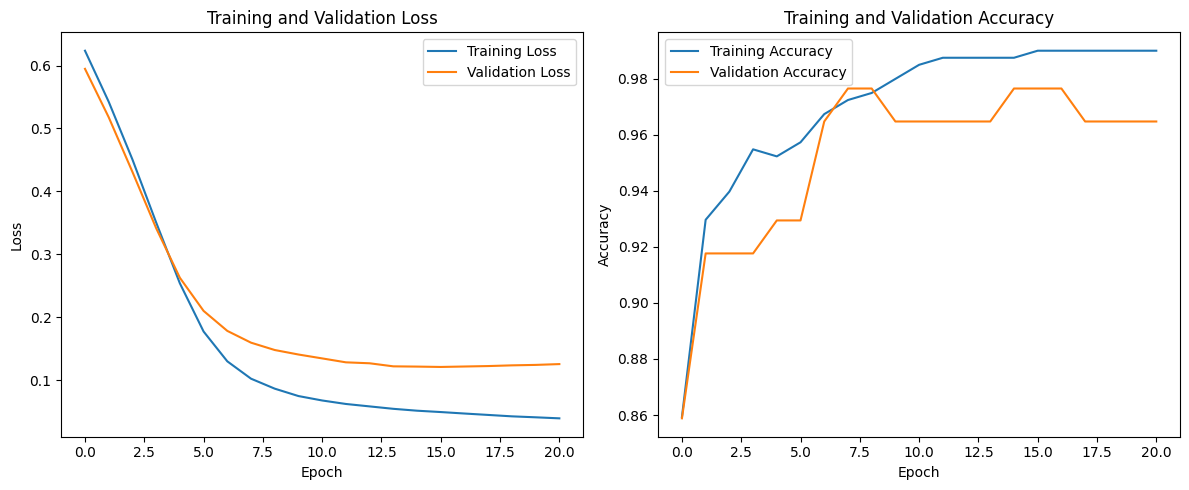

In [ ]:
class BreastCancerNN(nn.Module):
    def __init__(self, input_size):  # This is required to properly set up a PyTorch neural network
        super(BreastCancerNN, self).__init__()

        # Create the layers of our network:
        # First layer: takes our features as input and outputs 30 values
        self.layer1 = nn.Linear(input_size, 30)
        # Second layer: takes 30 values and outputs 30 values
        self.layer2 = nn.Linear(30, 30)
        # Output layer: takes 30 values and outputs 1 value (cancer prediction)
        self.output = nn.Linear(30, 1)

    def forward(self, x):  # This defines how data flows through our network
        # passes the input through the first layer, then applies the ReLU activation function (turns negative values to zero)
        x = torch.relu(self.layer1(x))
        # Apply second layer, then ReLU again
        x = torch.relu(self.layer2(x))
        # Apply output layer, then sigmoid to get probability between 0 and 1
        x = torch.sigmoid(self.output(x))
        return x

# Get number of input features from our training data
input_size = X_train_scaled.shape[1]

# Create our neural network model
model = BreastCancerNN(input_size)

# Set up binary cross-entropy loss - good for binary classification problems
criterion = nn.BCELoss()

# Choose Adam optimizer with learning rate of 0.001
# Optimizer is what updates the weights of our network based on errors
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Set maximum number of training rounds (epochs)
num_epochs = 100

# Early stopping: we'll stop training if validation doesn't improve for this many epochs
patience = 5

# Create lists to store performance metrics for plotting
train_losses = []    # Training loss per epoch
val_losses = []      # Validation loss per epoch
train_accs = []      # Training accuracy per epoch
val_accs = []        # Validation accuracy per epoch

# Set up early stopping variables
# Start with infinite loss - any real loss will be better than this
best_val_loss = float('inf')
# Counter for epochs without improvement
epochs_without_improvement = 0
# Variable to store the best model
best_model = None

# Begin training loop - runs for each epoch
for epoch in range(num_epochs):

    # ----- TRAINING PHASE -----
    # Set model to training mode - enables gradient tracking
    model.train()

    # Initialize counters for this epoch
    train_loss = 0.0
    train_correct = 0

    for inputs, labels in train_loader:  # Loop through each batch of training data
        optimizer.zero_grad()  # Reset gradients from previous batch
        outputs = model(inputs)  # Forward pass: get predictions from model
        loss = criterion(outputs, labels)  # Calculate loss (error) between predictions and actual values
        loss.backward()  # Backward pass: calculate gradients
        optimizer.step()  # Update model weights using optimizer
        train_loss += loss.item() * inputs.size(0)  # Add this batch's loss to total loss (weighted by batch size)
        predicted = (outputs >= 0.5).float()  # Convert outputs to binary predictions (0 or 1)
        train_correct += (predicted == labels).sum().item()  # Count how many predictions were correct

    # Calculate average loss and accuracy for this epoch
    train_loss /= len(train_dataset)
    train_acc = train_correct / len(train_dataset)

    # ----- VALIDATION PHASE -----
    # Set model to evaluation mode - disables gradient tracking
    model.eval()

    # Initialize counters for validation
    val_loss = 0.0
    val_correct = 0

    with torch.no_grad():  # No need to calculate gradients during validation
        for inputs, labels in val_loader:  # Loop through each batch of validation data
            outputs = model(inputs)  # Get predictions from model
            loss = criterion(outputs, labels)  # Calculate loss
            val_loss += loss.item() * inputs.size(0)  # Add this batch's loss to total validation loss
            predicted = (outputs >= 0.5).float()  # Convert outputs to binary predictions
            val_correct += (predicted == labels).sum().item()  # Count correct predictions

    # Calculate average validation loss and accuracy
    val_loss /= len(val_dataset)
    val_acc = val_correct / len(val_dataset)

    # Store metrics for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Print progress report every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

    # ----- EARLY STOPPING CHECK -----
    # If validation loss improved
    if val_loss < best_val_loss:
        # Update best validation loss
        best_val_loss = val_loss
        # Reset counter
        epochs_without_improvement = 0
        # Save the current model as the best one
        best_model = model.state_dict().copy()
    else:
        # Increment counter if no improvement
        epochs_without_improvement += 1
        # Check if we should stop early
        if epochs_without_improvement >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

# Load the best model (the one with lowest validation loss)
model.load_state_dict(best_model)

# Create plots as required in the assignment
plt.figure(figsize=(12, 5))

# Plot 1: Training and Validation Loss
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot 2: Training and Validation Accuracy
plt.subplot(1, 2, 2)  # 1 row, 2 columns, second plot
plt.plot(train_accs, label='Training Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Adjust layout and display plots
plt.tight_layout()
plt.show()

Based on charts best stop point seems to be less than 10 epoch:The model begins to overfit after epoch 10 (when training loss keeps decreasing while validation is flatten out). The best stopping point is around epoch 10-12 where validation metrics plateau despite continued improvement in training performance. For this exercice we will use exact stopping point as 10 epoch for our predefined NN structure, 30,30,1

Epoch 1/10, Train Loss: 0.7097, Val Loss: 0.6644, Train Acc: 0.3920, Val Acc: 0.6824
Epoch 2/10, Train Loss: 0.6170, Val Loss: 0.5747, Train Acc: 0.8693, Val Acc: 0.8941
Epoch 3/10, Train Loss: 0.4997, Val Loss: 0.4622, Train Acc: 0.9372, Val Acc: 0.9412
Epoch 4/10, Train Loss: 0.3704, Val Loss: 0.3460, Train Acc: 0.9422, Val Acc: 0.9412
Epoch 5/10, Train Loss: 0.2554, Val Loss: 0.2575, Train Acc: 0.9422, Val Acc: 0.9529
Epoch 6/10, Train Loss: 0.1812, Val Loss: 0.2011, Train Acc: 0.9472, Val Acc: 0.9529
Epoch 7/10, Train Loss: 0.1368, Val Loss: 0.1659, Train Acc: 0.9523, Val Acc: 0.9765
Epoch 8/10, Train Loss: 0.1108, Val Loss: 0.1455, Train Acc: 0.9673, Val Acc: 0.9647
Epoch 9/10, Train Loss: 0.0956, Val Loss: 0.1328, Train Acc: 0.9698, Val Acc: 0.9765
Epoch 10/10, Train Loss: 0.0841, Val Loss: 0.1244, Train Acc: 0.9749, Val Acc: 0.9647


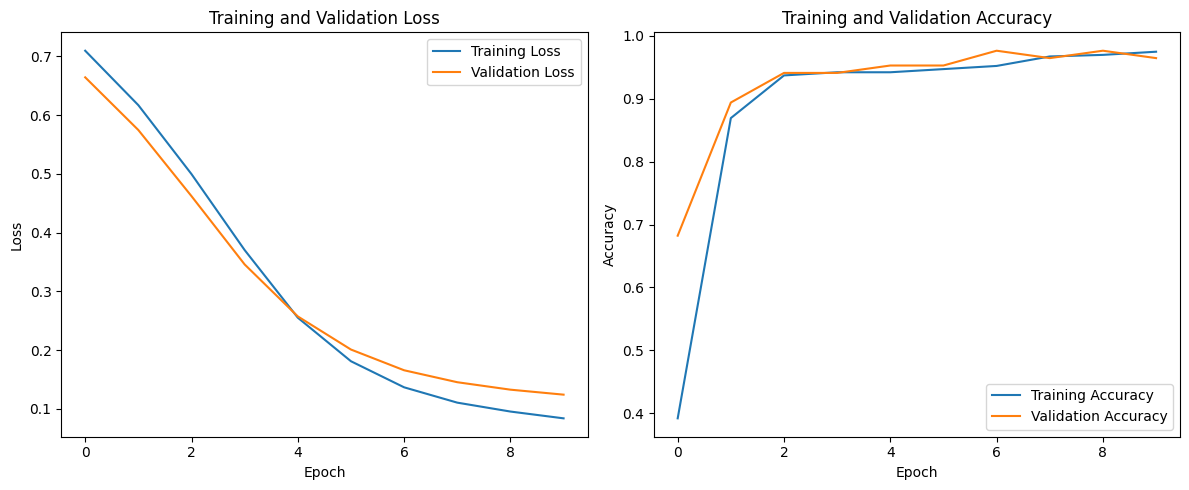

In [ ]:
# Training with exact stoping point
# same as before
class BreastCancerNN(nn.Module):
    def __init__(self, input_size):  # This is required to properly set up a PyTorch neural network
        super(BreastCancerNN, self).__init__()

        # Create the layers of our network:
        # First layer: takes our features as input and outputs 30 values
        self.layer1 = nn.Linear(input_size, 30)
        # Second layer: takes 30 values and outputs 30 values
        self.layer2 = nn.Linear(30, 30)
        # Output layer: takes 30 values and outputs 1 value (cancer prediction)
        self.output = nn.Linear(30, 1)

    def forward(self, x):  # This defines how data flows through our network
        # passes the input through the first layer, then applies the ReLU activation function (turns negative values to zero)
        x = torch.relu(self.layer1(x))
        # Apply second layer, then ReLU again
        x = torch.relu(self.layer2(x))
        # Apply output layer, then sigmoid to get probability between 0 and 1
        x = torch.sigmoid(self.output(x))
        return x

# Get number of input features from our training data
input_size = X_train_scaled.shape[1]

# Create our neural network model
model = BreastCancerNN(input_size)

# Set up binary cross-entropy loss - good for binary classification problems
criterion = nn.BCELoss()

# Choose Adam optimizer with learning rate of 0.001
# Optimizer is what updates the weights of our network based on errors
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Initialize empty lists to store metrics so that it does not get data from previous training with earlystopping
train_losses = []
val_losses = []
train_accs = []
val_accs = []

# Set maximum number of training rounds (epochs)
num_epochs = 10  # Explicitly set to 10

# Removed early stopping logic
for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        predicted = (outputs >= 0.5).float()
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_dataset)
    train_acc = train_correct / len(train_dataset)

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            predicted = (outputs >= 0.5).float()
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_dataset)
    val_acc = val_correct / len(val_dataset)

    # Store metrics for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Print progress report every epoch
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
          f'Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

# After training, plot the results (same as before)
plt.figure(figsize=(12, 5))

# Plot 1: Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot 2: Training and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Training Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Part e)

In [ ]:
# Calculate accuracy, recall, precision and f1 scores on the test set and print them.
# Evaluate the model on the test set
model.eval()  # Set the model to evaluation mode
y_true = []  # Empty list to store the true labels/targets
y_pred = []  # Empty list to store the predicted binary values (0 or 1)
y_prob = []  # Empty list to store the raw probability outputs from the model

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        predicted = (outputs >= 0.5).float()

        # Convert tensors to numpy arrays and collect
        y_true.extend(labels.cpu().numpy()) # Add true labels to our list
        y_pred.extend(predicted.cpu().numpy()) # Add binary predictions to our list (after thresholding at 0.5)
        y_prob.extend(outputs.cpu().numpy()) # Add raw probabilities to our list (before thresholding)

# Convert lists to numpy arrays for sklearn metrics
y_true = np.array(y_true).flatten()
y_pred = np.array(y_pred).flatten()
y_prob = np.array(y_prob).flatten()

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print results
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test F1 Score: {f1:.4f}")

Test Accuracy: 0.9651
Test Recall: 0.9032
Test Precision: 1.0000
Test F1 Score: 0.9492


Part f)


Confusion Matrix:
[[55  0]
 [ 3 28]]


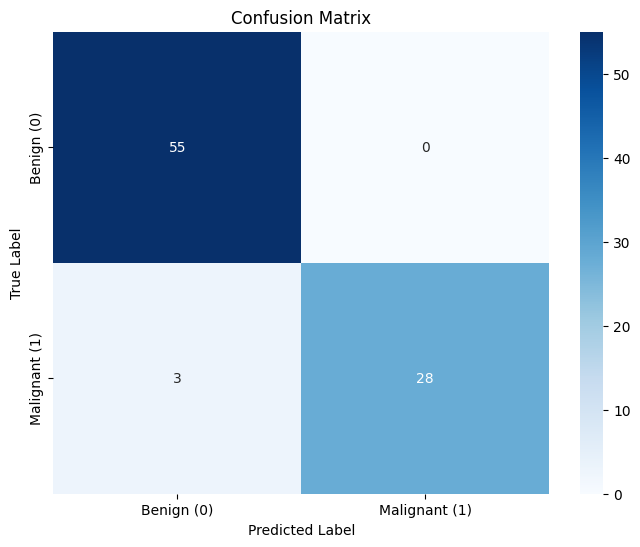


Manual calculation of accuracy:
Accuracy = (TP + TN) / (TP + TN + FP + FN) = (28 + 55) / (28 + 55 + 0 + 3) = 0.9651
Does it match the sklearn accuracy? Yes


In [ ]:
# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Benign (0)', 'Malignant (1)'],
           yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Calculate accuracy manually from confusion matrix
tn, fp, fn, tp = conf_matrix.ravel()
manual_accuracy = (tp + tn) / (tp + tn + fp + fn)

print("\nManual calculation of accuracy:")
print(f"Accuracy = (TP + TN) / (TP + TN + FP + FN) = ({tp} + {tn}) / ({tp} + {tn} + {fp} + {fn}) = {manual_accuracy:.4f}")
print(f"Does it match the sklearn accuracy? {'Yes' if np.isclose(accuracy, manual_accuracy) else 'No'}")

Part g)

In [ ]:
# Create a dataframe from the test set
df_test = pd.DataFrame({
    'id': ids_test.values,
    'diagnosis': y_true,
    'predicted_diagnosis': y_pred,
    'probability': y_prob,
    'success': y_true == y_pred
})

# Convert 'success' to 1s and 0s
df_test['success'] = df_test['success'].astype(int)

print("\nTest dataframe (df_test):")
print(df_test.head())



Test dataframe (df_test):
       id  diagnosis  predicted_diagnosis  probability  success
0  905520        0.0                  0.0     0.005041        1
1  903483        0.0                  0.0     0.000194        1
2  899987        1.0                  1.0     0.999992        1
3  904302        0.0                  0.0     0.001221        1
4  862965        0.0                  0.0     0.011165        1


Part h)

In [ ]:
import pickle
# Save the model weights
with open('breast_cancer_model.pkl', 'wb') as f:
    pickle.dump(model.state_dict(), f)

print("\nModel weights saved to 'breast_cancer_model.pkl'")


Model weights saved to 'breast_cancer_model.pkl'


Part i)

In [ ]:
# Initialize a new model2 with the same architecture
model2 = BreastCancerNN(input_size)

# Load the saved weights
with open('breast_cancer_model.pkl', 'rb') as f:
    model2.load_state_dict(pickle.load(f))

# Evaluate model2 on the test set
model2.eval()
y_pred2 = []
y_prob2 = []

with torch.no_grad():
    for inputs, _ in test_loader:
        outputs = model2(inputs)
        predicted = (outputs >= 0.5).float()
        y_pred2.extend(predicted.numpy().flatten())
        y_prob2.extend(outputs.numpy().flatten())

y_pred2 = np.array(y_pred2)
y_prob2 = np.array(y_prob2)

# Calculate metrics with loaded model
accuracy2 = accuracy_score(y_true, y_pred2)
recall2 = recall_score(y_true, y_pred2)
precision2 = precision_score(y_true, y_pred2)
f1_2 = f1_score(y_true, y_pred2)

print("\nTest Metrics using loaded model (model2):")
print(f"Accuracy: {accuracy2:.4f}")
print(f"Recall: {recall2:.4f}")
print(f"Precision: {precision2:.4f}")
print(f"F1 Score: {f1_2:.4f}")


Test Metrics using loaded model (model2):
Accuracy: 0.9651
Recall: 0.9032
Precision: 1.0000
F1 Score: 0.9492


# Problem 2: Hyperparameter tuning for Breast Cancer Classification ANN model in PyTorch (30 pts)
(You have to use PyTorch in this problem, Tensorflow will not be accepted as answer.)

a) Select a optimizer and a reasonable learning rate; we will not tune it.
Determine some values for number of hidden layers and number of neurons (assume all hidden layers have the same number of neurons).
Perform hyperparameter tuning by using grid search in this two dimensional hyperparameter space, using automatic early stopping. Grid search here means you will train the model for all possible sets of hyper

b) Make a matrix plot as done in Lecture_7.ipyb where each cell is colored based on the accuracy, and accuracy values are shown within each cell. Report which hyperparameter set (number of neurons, number of hidden layers) worked the best in your experiment based on this matrix plot.


#### Part a)

In [ ]:
# Select optimizer and learning rate (fixed for all models)
OPTIMIZER = optim.Adam
LEARNING_RATE = 0.001
BATCH_SIZE = 32
MAX_EPOCHS = 50
PATIENCE = 5

# Define hyperparameter search space
HIDDEN_LAYERS_OPTIONS = [1, 2, 3]  # Number of hidden layers to explore
HIDDEN_NEURONS_OPTIONS = [10, 20, 30, 40, 50]  # Number of neurons per layer

# Prepare data for grid search similar to problem 1
train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
train_targets_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
val_targets_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)

In [ ]:
# Create flexible NN
class BreastCancerNN(nn.Module):
    def __init__(self, input_size, hidden_layers, hidden_neurons):
        super(BreastCancerNN, self).__init__()

        # Create a list to hold all layers
        layers = []

        # First layer: input to first hidden layer
        layers.append(nn.Linear(input_size, hidden_neurons))
        layers.append(nn.ReLU())

        # Add additional hidden layers
        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(hidden_neurons, hidden_neurons))
            layers.append(nn.ReLU())

        # Output layer (single output for binary classification)
        layers.append(nn.Linear(hidden_neurons, 1))
        layers.append(nn.Sigmoid())  # Sigmoid for binary classification

        # Create sequential model from layers
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [ ]:
# Function to train and evaluate a single model with specified architecture
def train_and_evaluate_model(input_size, hidden_layers, hidden_neurons, show_plots=True):
    """
    Train a model with the specified architecture and return the best validation accuracy
    """
    # Create model
    model = BreastCancerNN(input_size, hidden_layers, hidden_neurons)

    # Define loss function and optimizer
    criterion = nn.BCELoss()
    optimizer = OPTIMIZER(model.parameters(), lr=LEARNING_RATE)

    # Create data loaders
    train_dataset = TensorDataset(train_tensor, train_targets_tensor.view(-1, 1))
    val_dataset = TensorDataset(val_tensor, val_targets_tensor.view(-1, 1))

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Training tracking variables
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    best_val_loss = float('inf')
    best_epoch = 0
    epochs_without_improvement = 0
    best_model_state = None

    # Main training loop
    for epoch in range(MAX_EPOCHS):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, targets in train_loader:
            # Forward pass
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Track statistics
            train_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            train_correct += (predicted == targets).sum().item()
            train_total += targets.size(0)

        # Calculate average training metrics
        avg_train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)

                # Track statistics
                val_loss += loss.item() * inputs.size(0)
                predicted = (outputs > 0.5).float()
                val_correct += (predicted == targets).sum().item()
                val_total += targets.size(0)

        # Calculate average validation metrics
        avg_val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        # Store metrics
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            best_model_state = model.state_dict().copy()
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f'Early stopping at epoch {epoch+1}, best val loss: {best_val_loss:.4f}')
                break

    # Load the best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Plot training/validation curves
    if show_plots:
        plt.figure(figsize=(12, 5))

        # Loss plot
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Training Loss')
        plt.plot(val_losses, label='Validation Loss')
        plt.title(f'Loss (Layers: {hidden_layers}, Neurons: {hidden_neurons})')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()

        # Accuracy plot
        plt.subplot(1, 2, 2)
        plt.plot(train_accs, label='Training Accuracy')
        plt.plot(val_accs, label='Validation Accuracy')
        plt.title(f'Accuracy (Layers: {hidden_layers}, Neurons: {hidden_neurons})')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

        plt.tight_layout()
        plt.show()

    # Return the best validation accuracy and best epoch
    best_val_acc = max(val_accs) * 100  # Convert to percentage
    print(f"Best model achieved at epoch {best_epoch} with validation accuracy {best_val_acc:.2f}%")
    return best_val_acc, best_epoch, model if best_model_state is not None else None

#### Part b)

Grid Search for Optimal Hyperparameters

Training model with 1 hidden layer(s) and 10 neurons per layer
Best model achieved at epoch 49 with validation accuracy 98.82%
Validation accuracy: 98.82%, best epoch: 49

Training model with 1 hidden layer(s) and 20 neurons per layer
Early stopping at epoch 34, best val loss: 0.1346
Best model achieved at epoch 29 with validation accuracy 97.65%
Validation accuracy: 97.65%, best epoch: 29

Training model with 1 hidden layer(s) and 30 neurons per layer
Early stopping at epoch 41, best val loss: 0.1335
Best model achieved at epoch 36 with validation accuracy 97.65%
Validation accuracy: 97.65%, best epoch: 36

Training model with 1 hidden layer(s) and 40 neurons per layer
Early stopping at epoch 40, best val loss: 0.1306
Best model achieved at epoch 35 with validation accuracy 97.65%
Validation accuracy: 97.65%, best epoch: 35

Training model with 1 hidden layer(s) and 50 neurons per layer
Early stopping at epoch 27, best val loss: 0.1469
Best mod

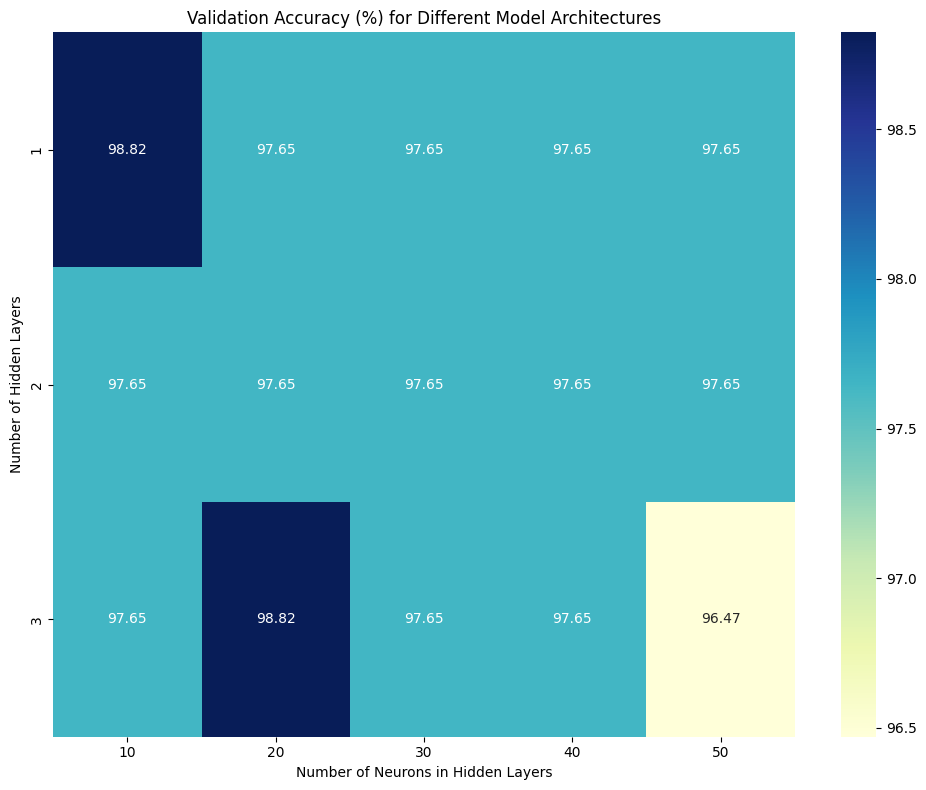


Best Hyperparameters:
Number of Hidden Layers: 1
Number of Neurons per Hidden Layer: 10
Best Validation Accuracy: 98.82%


In [ ]:
# Perform grid search over hyperparameters and create matrix plot

def perform_grid_search():
    print("Grid Search for Optimal Hyperparameters")

    # Get input size from training data
    input_size = train_tensor.shape[1]

    # Initialize results matrix
    results_matrix = np.zeros((len(HIDDEN_LAYERS_OPTIONS), len(HIDDEN_NEURONS_OPTIONS)))

    # Perform grid search
    for i, num_layers in enumerate(HIDDEN_LAYERS_OPTIONS):
        for j, num_neurons in enumerate(HIDDEN_NEURONS_OPTIONS):
            print(f"\nTraining model with {num_layers} hidden layer(s) and {num_neurons} neurons per layer")

            # Train and evaluate model
            accuracy, best_epoch, _ = train_and_evaluate_model(
                input_size=input_size,
                hidden_layers=num_layers,
                hidden_neurons=num_neurons,
                show_plots=False  # Suppress individual plots
            )

            # Store result
            results_matrix[i, j] = accuracy
            print(f"Validation accuracy: {accuracy:.2f}%, best epoch: {best_epoch}")

    # Create matrix plot with heatmap
    plt.figure(figsize=(10, 8))
    heatmap = sns.heatmap(
        results_matrix,
        annot=True,  # Show accuracy value in each cell
        fmt='.2f',   # Format accuracy to 2 decimal places
        cmap='YlGnBu',
        xticklabels=HIDDEN_NEURONS_OPTIONS,
        yticklabels=HIDDEN_LAYERS_OPTIONS
    )
    plt.title('Validation Accuracy (%) for Different Model Architectures')
    plt.xlabel('Number of Neurons in Hidden Layers')
    plt.ylabel('Number of Hidden Layers')
    plt.tight_layout()
    plt.show()

    # Find best hyperparameters
    best_idx = np.unravel_index(np.argmax(results_matrix), results_matrix.shape)
    best_layers = HIDDEN_LAYERS_OPTIONS[best_idx[0]]
    best_neurons = HIDDEN_NEURONS_OPTIONS[best_idx[1]]
    best_accuracy = results_matrix[best_idx]

    print("\nBest Hyperparameters:")
    print(f"Number of Hidden Layers: {best_layers}")
    print(f"Number of Neurons per Hidden Layer: {best_neurons}")
    print(f"Best Validation Accuracy: {best_accuracy:.2f}%")

    return best_layers, best_neurons, best_accuracy

# Run the grid search if data is available
if 'train_tensor' in locals() and 'val_tensor' in locals():
    best_layers, best_neurons, best_accuracy = perform_grid_search()
else:
    print("Please run Problem 1 first to create the required tensors (train_tensor, val_tensor, etc.)")

Based on this very simple model is enough with 1 hidden layer with 10 neurons, early stopping at epoch: 49
BUT since we do prefer more layers with less neuron due to depth efficiency and less number of epochs needed
CONCLUSION IS TO CHOOSE 3 LAYERS WITH 20 NEURONS, SAME ACCURACY > Validation accuracy: 98.82%, early stop point: 13 epochs
Other solutions have more epochs, or more neurons (complex)